In [34]:
from neural_transport.litmodule import NeuralTransport
from neural_transport.datamodule import CarbonDataModule, CarbonDataset

import torch

import time as pytime

from pathlib import Path

from neural_transport.tools.conversion import *

import numpy as np
import xarray as xr
import xskillscore

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
model = NeuralTransport.load_from_checkpoint("/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250912_dev/singlestep/checkpoints/last.ckpt")

In [3]:
model

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [4]:
# data_kwargs

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=31,
    target_vars=["co2massmix", "airmass"],
    forcing_vars=[
        "gph_bottom",
        "gph_top",
        "p_bottom",
        "p_top",
        "q",
        "t",
        "u",
        "v",
        "blh",
        "cell_area",
        "co2flux_anthro",
        "co2flux_land",
        "co2flux_ocean",
        "orography",
        "tisr",
    ],
    compute=False,
    # time_interval=["1990-01-01", "2014-12-31"],
)

In [5]:
# lit_module_kwargs

from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.models.wrappers_registry import MODELWRAPPERS

TARGET_VARS = ["co2massmix"]
# Uncomment for conditional Flow Matching
FORCING_VARS_1D = [
    # "flow_time"
]
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

cos_lat = np.cos(np.radians(lat))[:, None, None].repeat(len(lon), axis=1).reshape(-1, 1)
cos_lat = cos_lat / np.mean(cos_lat)

ds_stats = xr.open_zarr(
    f"/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/train/carbontracker_{grid}_{vertical_levels}_{freq}_stats.zarr"
).compute()

inv_std = {
    k: 1
    / (ds_stats[f"{k}_delta"].sel(stats="std").where(lambda x: x > 1e-14, 1).values)
    ** 2
    for k in TARGET_VARS  # CARBOSCOPE_CARBON3D_VARS
}

weights = {k: cos_lat * inv_std[k] for k in inv_std}

LOSS_WEIGHTS = {k: (10 * v / LEN_ALL_TARGET_VARS) for k, v in weights.items()}

METRIC_WEIGHTS = {f"{k}_delta": cos_lat for k in TARGET_VARS}


MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

regulargrid_kwargs = dict( # for RegularGridModel
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=False,
    add_surfflux=False,
    dt=60 * 60 * 6,
    massfixer="",
    targshift=True,
)

wrapper_kwargs = dict( # for RegularGridModel (FlowMatching)
    **regulargrid_kwargs,
    model_kwargs=dict( # for FlowMatching
        submodel="unet",
        model_kwargs=dict( # for RegularGridModel (UNet)
            **regulargrid_kwargs,
            model_kwargs=dict( # for UNet
                in_chans=LEN_ALL_VARS + 1, # + 1 for flow_time
                out_chans=LEN_ALL_TARGET_VARS,
                embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
                act="leakyrelu",
                norm="batch",
                enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
                dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
                in_interpolation="bilinear",
                out_interpolation="nearest-exact",
                out_clip=None,
            ),
        ),
        return_intermediates=True,
        method="midpoint",  # 'midpoint' or 'euler'
        nlev=nlev,
        step_size=0.1,
    ),
)

flow = MODELWRAPPERS["flowmatching"](**wrapper_kwargs)

flow.n_samples = 10

lit_module_kwargs = dict(
    model=flow,
    model_kwargs=wrapper_kwargs["model_kwargs"],
    loss="mse",
    loss_kwargs=dict(
        weights=LOSS_WEIGHTS, spectral_power_weight=0.0, nlat=len(lat), nlon=len(lon), normalize_batch=True,
    ),
    metrics=[
        dict(name=m, kwargs=dict(weights=METRIC_WEIGHTS))
        for m in ["rmse", "r2", "nse", "rabsbias", "rrmse"]
    ],
    # + [dict(name="mass_rmsev2", kwargs=dict(molecule=m)) for m in ["co2"]],
    no_grad_step_shedule=None,
    lr=1e-3,
    weight_decay=0.1,
    lr_shedule_kwargs=dict(
        warmup_steps=1000, halfcosine_steps=99000, min_lr=3e-7, max_lr=1.0
    ),
    val_dataloader_names=["singlestep"],
    plot_kwargs=dict(
        variables=["co2molemix"],
        layer_idxs=[0, 3, 5, 8],
        n_samples=10,
        dataset="carbontracker",
        grid=grid,
        vertical_levels=vertical_levels,
        max_workers=32,
    ),
)

In [6]:
dset = CarbonDataModule(**data_kwargs)
dset.setup("fit")

In [7]:
dl_val = dset.val_dataloader()
batch_val = next(iter(dl_val[0]))
batch_val = {k: v.squeeze(1) if isinstance(v, torch.Tensor) else v for k, v in batch_val.items()}

In [8]:
model.to(device="cpu")
model.train()

NeuralTransport(
  (model): FlowMatching(
    (submodel): UNet(
      (enc_stages): ModuleList(
        (0): Sequential(
          (0): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(11, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1-3): 3 x Sequential(
          (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (1): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), bias=False)
            (act): LeakyReLU(negative_slope=0.01)
            (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (2): ResBlock(
            (pad): PeriodicPadding()
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1

In [9]:
preds = model.model(batch_val)

In [10]:
f"Predictions: Standard Deviation {preds['co2massmix'].std()}, Mean {preds['co2massmix'].mean()}"

'Predictions: Standard Deviation 1.0015819072723389, Mean 0.09196516126394272'

In [11]:
batch_val["co2massmix_next"].std(), batch_val["co2massmix_next"].mean()

(tensor(8.3530), tensor(614.3007))

In [12]:
batch_normalized = {}
for v in preds:
    for suffix in ['', '_next']:
        key = f"{v}{suffix}"
        if key in batch_val:
            mean = batch_val[f"{v}_offset"]
            std = batch_val[f"{v}_scale"]
            x_in_curr = (batch_val[key] - mean) / std
            batch_normalized[key] = x_in_curr

In [13]:
f'Batch: Standard Deviation: {batch_normalized["co2massmix_next"].std()}, Mean: {batch_normalized["co2massmix_next"].mean()}'

'Batch: Standard Deviation: 0.5031848549842834, Mean: 1.8334089517593384'

In [14]:
model.eval()
model.return_intermediates = True

In [15]:
def load_dataset(data_path, data_kwargs):

    dataset = CarbonDataset(
        data_path=data_path,
        dataset=data_kwargs["dataset"],
        grid=data_kwargs["grid"],
        vertical_levels=data_kwargs["vertical_levels"],
        freq=data_kwargs["freq"],
        n_timesteps=1,
        target_vars=data_kwargs["target_vars"],
        forcing_vars=data_kwargs["forcing_vars"],
        load_obspack=True,
        new_zarr=True,
    )

    return dataset

data_path_forecast = Path(
    "/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker/test/"
)

dataset = load_dataset(data_path_forecast, data_kwargs)

In [16]:
import importlib
import neural_transport.inference.generative as generative
importlib.reload(generative)

<module 'neural_transport.inference.generative' from '/Net/Groups/BGI/work_5/CO2_diffusion/neural_transport/neural_transport/inference/generative.py'>

In [17]:
outpath = Path("test_preds")
ds_all = generative.iterative_generate(
    model,
    dataset,
    outpath=outpath,
    rollout=False,
    device="cuda",
    zarr_filename=None,
    freq=None,
    zero_surfflux=False,
    remap=False,
    target_vars_3d=["co2massmix"],
    target_vars_2d=[],
    save_obs=False,   # True only possible if "gph_bottom", "gph_top" are in batch
    n_samples=10,   # keep small for a test
)

FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})


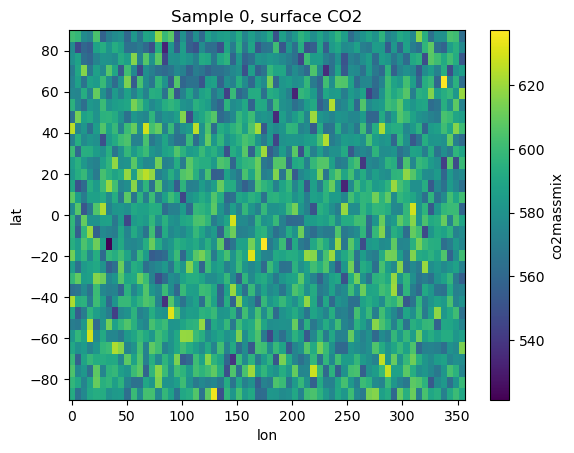

In [18]:
da = ds_all["co2massmix"].isel(sample=0, level=0).compute()
da.plot(
    x="lon", y="lat", cmap="viridis"
)
plt.title("Sample 0, surface CO2")
plt.show()

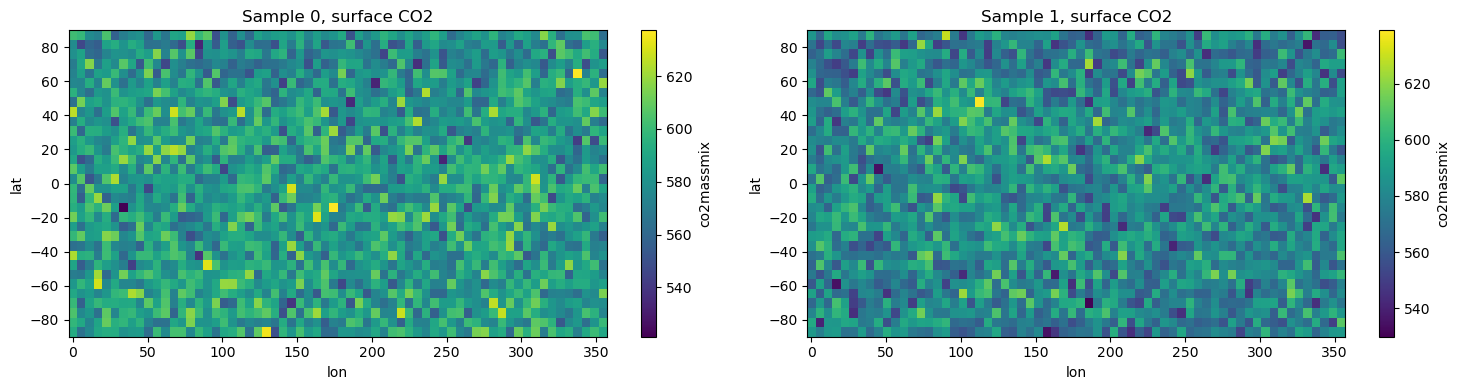

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, ax in enumerate(axes):
    da = ds_all["co2massmix"].isel(sample=i, level=0).compute()
    da.plot(
        x="lon", y="lat", ax=ax, cmap="viridis"
    )
    ax.set_title(f"Sample {i}, surface CO2")

plt.tight_layout()
plt.show()


In [20]:
import neural_transport.training.train as train
importlib.reload(train)

<module 'neural_transport.training.train' from '/Net/Groups/BGI/work_5/CO2_diffusion/neural_transport/neural_transport/training/train.py'>

In [21]:
run_dir = Path.cwd()
ckpt = "best"
massfixer = ["scale"]

In [22]:
train.predict(
        run_dir / "singlestep",
        data_path_forecast,
        data_kwargs,
        device="cuda",
        freq=freq,
        ckpt=ckpt,
        lit_module_kwargs=lit_module_kwargs,
        massfixer=massfixer,
    )

Generating /Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250912_dev/singlestep/checkpoints/Epoch=5-Step=2328-LossVal=46.807968.ckpt best CKPT
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMappingWarningOnValuesAccess({'level': 10, 'lat': 32, 'lon': 64, 'time': 10, 'sample': 1})
FrozenMap

In [23]:
target_path = (
        data_path_forecast
        / f"{data_kwargs['dataset']}_{data_kwargs['grid']}_{data_kwargs['vertical_levels']}_{data_kwargs['freq']}.zarr"
    )

In [24]:
pred_path = (
        run_dir
        / "singlestep"
        / "preds"
        / f"ckpt={ckpt}_massfixer={massfixer}"
        / f"co2_pred_rollout_{freq}.zarr"
    )

In [25]:
FM = True

# Just for testing purposes, as observations are turned off
def compute_score_df(targs, preds, freq="QS"):
    pass

def compute_local_scores(obs_preds, freq="QS"):
    pass

def load_pred_targ(target_path, pred_path):
    targ = xr.open_zarr(target_path)
    co2targ = xr.merge(
        [
            targ["variables_3d"].to_dataset("vari_3d"),
            targ["variables_2d"].to_dataset("vari_2d"),
        ]
    )

    co2pred = xr.open_zarr(pred_path)
    return co2targ, co2pred

def score(target_path, pred_path, obs_pred_path=None, freq="QS", FM=False):
    co2targ, co2pred = load_pred_targ(target_path, pred_path)
    co2pred = co2pred.isel(time=slice(1, None))
    co2targ = co2targ.isel(time=slice(1, None)).isel(time=slice(len(co2pred.time)))

    model_name = pred_path.parent.parent.parent.parent.name
    singlestep_or_rollout = pred_path.parent.parent.parent.name
    ckpt_name = pred_path.parent.name
    score_path = pred_path.parent.parent.parent / "scores" / ckpt_name

    print("co2targ dims:", co2targ.dims, co2targ.sizes)
    print("co2pred dims:", co2pred.dims, co2pred.sizes)
    
    metrics = {}
    if FM:
        df_full = compute_score_df_generate(co2targ, co2pred)
        df_full.index = pd.MultiIndex.from_product(
            [[f"{model_name}_{singlestep_or_rollout}_{ckpt_name}"], df_full.index],
            names=["model", "sample"],
        )
        print(df_full.index.get_level_values("sample").unique())
        score_path.mkdir(parents=True, exist_ok=True)
        df_full.to_csv(score_path / ("metrics_fullsamples.csv" if freq == "QS" else f"metrics_fullsamples_{freq}.csv"))

        idx = pd.IndexSlice
        df_summary = df_full.loc[idx[f"{model_name}_{singlestep_or_rollout}_{ckpt_name}", ["mean", "std"]], :]
        df_summary.to_csv(score_path / ("metrics.csv" if freq == "QS" else f"metrics_{freq}.csv"))
    else:
        metrics[f"{model_name}_{singlestep_or_rollout}_{ckpt_name}"] = compute_score_df(
            co2targ,
            co2pred,
            freq=freq,
        )
        df = pd.DataFrame(metrics).T
        score_path.mkdir(parents=True, exist_ok=True)
        df.to_csv(score_path / ("metrics.csv" if freq == "QS" else f"metrics_{freq}.csv"))

    if obs_pred_path:
        obspreds = xr.open_zarr(obs_pred_path)  # .isel(time = slice(1,None))

        print(f"Computing score for {obs_pred_path}")

        df = compute_local_scores(obs_preds=obspreds, freq=freq)

        df.to_csv(
            score_path
            / ("obs_metrics.csv" if freq == "QS" else f"obs_metrics_{freq}.csv")
        )


def compute_score_df_generate(targs, preds):
    """
    Compute metrics for generated samples where:
      - targs has dims: [time, level, lat, lon]
      - preds has dims: [sample, level, lat, lon] (or [sample, (flow)time, level, lat, lon] if trajectory)
    """

    preds["lat"] = targs["lat"]
    preds["lon"] = targs["lon"]
    preds["level"] = targs["level"]
    
    targs = targs.isel(time=-1)
    if "time" in preds.dims:
        preds = preds.isel(time=-1)

    start = pytime.time()

    # Convert to mole fraction
    molemix_targ = massmix_to_molemix(targs.co2massmix).transpose("level", "lat", "lon")
    molemix_pred = massmix_to_molemix(preds.co2massmix).transpose("sample", "level", "lat", "lon")

    # Weights (cos(lat)) – no time dependence, just lat dimension
    weights = np.cos(np.deg2rad(targs.lat))
    _, weights = xr.broadcast(targs.co2massmix, weights)

    print(f"Data Loading {pytime.time() - start}")

    results = []

    for i in range(preds.sizes["sample"]):
        pred_i = molemix_pred.isel(sample=i)

        metrics = {}

        ### Metrics
        # Mass_RMSE
        # RelMass_RMSE
        start = pytime.time()

        # Mass balance metrics
        if "airmass" in targs and "airmass" in preds:
            targ_mass = (targs.co2massmix * targs.airmass) / 1e6
            pred_mass = (preds.co2massmix.isel(sample=i) * targs.airmass) / 1e6
        else:
            targ_mass = targs.co2massmix
            pred_mass = preds.co2massmix.isel(sample=i)

        targ_mass_sum = targ_mass.sum(["lat", "lon", "level"]).compute() / 3.664
        pred_mass_sum = pred_mass.sum(["lat", "lon", "level"]).compute() / 3.664

        metrics["Mass_RMSE"] = ((targ_mass_sum - pred_mass_sum) ** 2).mean().item() ** 0.5
        print(f"Mass RMSE {pytime.time() - start}")
        start = pytime.time()

        metrics["RelMass_RMSE"] = (
            ((targ_mass_sum - pred_mass_sum) / (targ_mass_sum + 1e-12)) ** 2
        ).mean().item() ** 0.5
        print(f"RelMass_RMSE {pytime.time() - start}")
        start = pytime.time()

        ### RMSE / R² across lat, lon, level
        mse = xskillscore.mse(
            molemix_targ.chunk({"lat": -1, "lon": -1, "level": -1}),
            pred_i.chunk({"lat": -1, "lon": -1, "level": -1}),
            dim=["lat", "lon", "level"],
            weights=weights,
        ).compute()

        metrics["RMSE_3D_co2molemix"] = mse.item() ** 0.5
        print(f"RMSE_3D_co2molemix {pytime.time() - start}")
        start = pytime.time()

        r = xskillscore.pearson_r(
            molemix_targ.chunk({"lat": -1, "lon": -1, "level": -1}),
            pred_i.chunk({"lat": -1, "lon": -1, "level": -1}),
            dim=["lat", "lon", "level"],
            weights=weights,
        ).compute()
        print(f"Pearson_R {pytime.time() - start}")
        start = pytime.time()

        metrics["PearsonCorrCoef_3D_co2molemix"] = r.item()
        metrics["R2_3D_co2molemix"] = (r**2).item()
        print(f"R2_3D_co2molemix {pytime.time() - start}")
        start = pytime.time()

        # Relative RMSE
        targ_mean = molemix_targ.weighted(weights).mean().compute().item()
        metrics["RelRMSE_3D_co2molemix"] = (mse.item() ** 0.5) / (targ_mean + 1e-12)
        print(f"RelRMSE_3D_co2molemix {pytime.time() - start}")
        start = pytime.time()

        # Per-dimension metrics (lat, lon, level)
        for dim in ["lat", "lon", "level"]:
            mse_dim = (
                ((pred_i - molemix_targ) ** 2)
                .weighted(weights)
                .mean(dim)
                .compute()
            )
            metrics[f"RMSE_{dim}_co2molemix"] = float(mse_dim.mean()**0.5)

            print(f"RMSE_{dim}_co2molemix {pytime.time() - start}")
            start = pytime.time()
        
        results.append(metrics)
    
    df = pd.DataFrame(results)
    df.loc["mean"] = df.mean()
    df.loc["std"] = df.std()

    print(f"Metrics {results} {pytime.time() - start}")

    return df


In [26]:
df = score(target_path=target_path, pred_path=pred_path, FM=FM)
df

co2targ dims: FrozenMappingWarningOnValuesAccess({'time': 9, 'level': 10, 'lat': 32, 'lon': 64}) Frozen({'time': 9, 'level': 10, 'lat': 32, 'lon': 64})
co2pred dims: FrozenMappingWarningOnValuesAccess({'lat': 32, 'time': 9, 'sample': 10, 'lon': 64, 'level': 10}) Frozen({'lat': 32, 'time': 9, 'sample': 10, 'lon': 64, 'level': 10})
Data Loading 0.005918025970458984
Mass RMSE 0.029498815536499023
RelMass_RMSE 0.0006437301635742188
RMSE_3D_co2molemix 0.02147960662841797
Pearson_R 0.03790140151977539
R2_3D_co2molemix 5.53131103515625e-05
RelRMSE_3D_co2molemix 0.02353501319885254
RMSE_lat_co2molemix 0.03214859962463379
RMSE_lon_co2molemix 0.03274655342102051
RMSE_level_co2molemix 0.032468557357788086
Mass RMSE 0.023684263229370117
RelMass_RMSE 0.0005524158477783203
RMSE_3D_co2molemix 0.02067875862121582
Pearson_R 0.03542923927307129
R2_3D_co2molemix 5.2928924560546875e-05
RelRMSE_3D_co2molemix 0.019234418869018555
RMSE_lat_co2molemix 0.03190922737121582
RMSE_lon_co2molemix 0.0310750007629394

In [27]:
import multiprocessing

movie_interval=["2018-01-01", "2018-03-31"]
num_workers=multiprocessing.cpu_count() // 2

In [28]:
import neural_transport.training.train as train
import neural_transport.inference.plot_results as plot_results
# import neural_transport.inference.analyse as analyse
importlib.reload(plot_results)
importlib.reload(train)
# importlib.reload(analyse)

<module 'neural_transport.training.train' from '/Net/Groups/BGI/work_5/CO2_diffusion/neural_transport/neural_transport/training/train.py'>

In [29]:
train.plot(
        target_path,
        pred_path,
        data_path_forecast,
        data_kwargs,
        movie_interval,
        num_workers,
    )

/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Net/Groups/BGI/work_5/scratch/jgross/neuraltransport/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Movie created at co2molemix_3d_anim_t0=2018-01-01-tend=2018-03-31.mp4


RuntimeError: Something has gone wrong. Use `verbose=True` to check if ffmpeg displays a problem

In [ ]:
# if "sample" in pred.dims:
#         pred_mean = pred.mean("sample")
#         pred_mean = pred_mean.transpose("level", "lat", "lon")
#         return pred_mean, targ
# else:
#     pred["time"] = targ["time"]
#     pred["level"] = targ["level"]
#     return pred, targ

In [30]:
samples = xr.open_zarr("/Net/Groups/BGI/work_5/CO2_diffusion/carbonbench/transport_models/carbontracker_lowres/flowmatching_dev/flowmatching_20250912_dev/singlestep/preds/ckpt=best_massfixer=default/co2_pred_rollout_QS.zarr")

In [35]:
samples

<xarray.Dataset> Size: 90MB
Dimensions:     (time: 10, level: 10, lat: 32, sample: 100, lon: 64)
Coordinates:
  * time        (time) datetime64[ns] 80B 2018-01-01 ... 2018-01-03T06:00:00
  * level       (level) float64 80B 1.013e+03 1.005e+03 995.0 ... 243.0 73.0
  * lat         (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * sample      (sample) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
  * lon         (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    co2massmix  (sample, lat, lon, level) float32 8MB dask.array<chunksize=(50, 16, 32, 5), meta=np.ndarray>
    trajectory  (sample, time, lat, lon, level) float32 82MB dask.array<chunksize=(25, 5, 16, 32, 5), meta=np.ndarray>

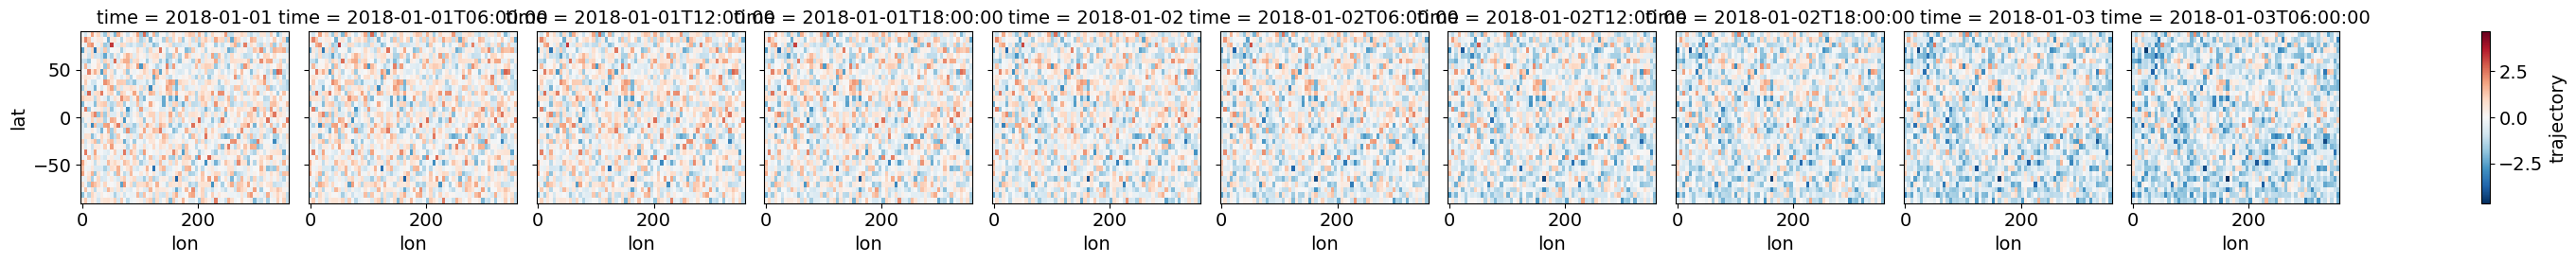

In [37]:
samples.trajectory.isel(sample=0, level=0).plot(col="time")
plt.show()

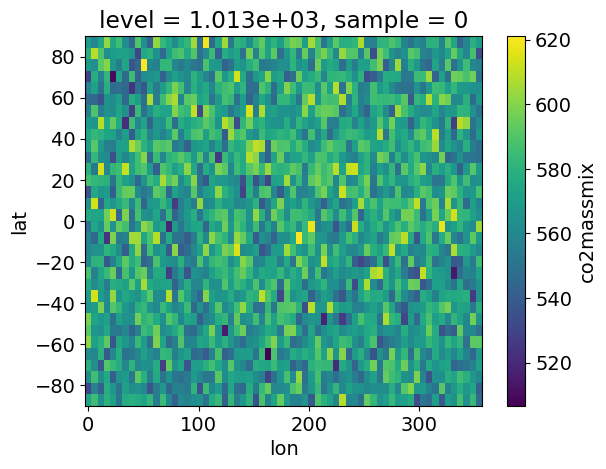

In [38]:
samples.co2massmix.isel(sample=0, level=0).plot()
plt.show()